[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Vaish\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Vaish\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Dataset Shape:
(50000, 2)

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Cleaning Reviews...

Logistic Regression Accuracy:
0.8893

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



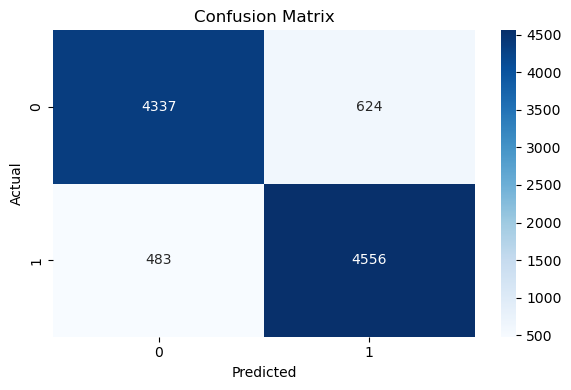


Naive Bayes Accuracy:
0.8546


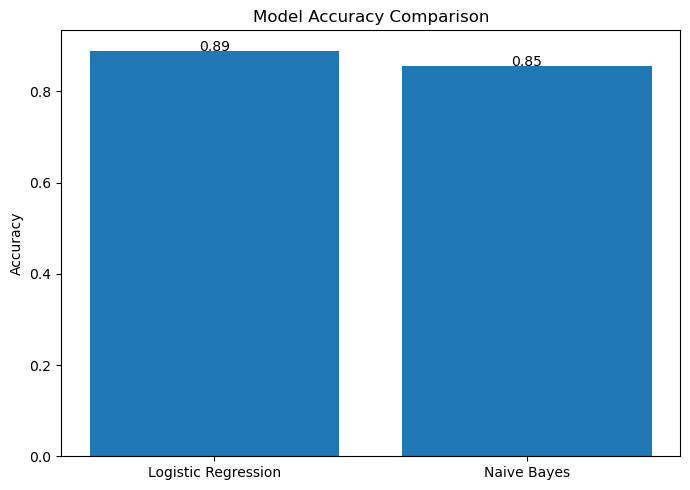


Review 1 Prediction:
Positive Review

Review 2 Prediction:
Negative Review

Dataset Size: 1000
Accuracy: 0.8300

Dataset Size: 5000
Accuracy: 0.8480

Dataset Size: 10000
Accuracy: 0.8735

Dataset Size: 50000
Accuracy: 0.8908


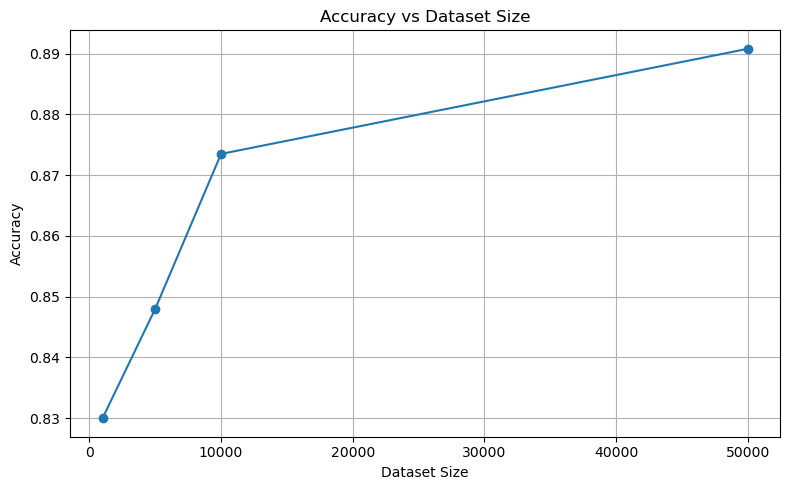


Project Completed Successfully


In [2]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

nltk.download('stopwords')
nltk.download('wordnet')

# Load Dataset
df = pd.read_csv("IMDB Dataset.csv")

print("Dataset Shape:")
print(df.shape)

print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

# Preprocessing
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

print("\nCleaning Reviews...")

df['clean_review'] = df['review'].apply(preprocess_text)

# Encode Labels
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

# Train/Test Split
X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("\nLogistic Regression Accuracy:")
print(lr_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))

# Confusion Matrix
cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Naive Bayes
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_predictions)

print("\nNaive Bayes Accuracy:")
print(nb_accuracy)

# Model Comparison
models = ['Logistic Regression', 'Naive Bayes']

accuracies = [lr_accuracy, nb_accuracy]

plt.figure(figsize=(7,5))

bars = plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center'
    )

plt.tight_layout()
plt.show()

# Custom Predictions
def predict_sentiment(review):

    cleaned_review = preprocess_text(review)

    review_vector = tfidf.transform([cleaned_review])

    prediction = lr_model.predict(review_vector)

    if prediction[0] == 1:
        return "Positive Review"

    return "Negative Review"

review1 = "This movie was absolutely amazing"

review2 = "Worst movie I have ever watched"

print("\nReview 1 Prediction:")
print(predict_sentiment(review1))

print("\nReview 2 Prediction:")
print(predict_sentiment(review2))

# Different Dataset Sizes
dataset_sizes = [1000, 5000, 10000, 50000]

accuracy_results = []

for size in dataset_sizes:

    subset_df = df.sample(n=size, random_state=42)

    X_subset = subset_df['clean_review']
    y_subset = subset_df['sentiment']

    X_train, X_test, y_train, y_test = train_test_split(
        X_subset,
        y_subset,
        test_size=0.2,
        random_state=42
    )

    tfidf_subset = TfidfVectorizer(max_features=5000)

    X_train_tfidf = tfidf_subset.fit_transform(X_train)

    X_test_tfidf = tfidf_subset.transform(X_test)

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train_tfidf, y_train)

    predictions = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, predictions)

    accuracy_results.append(accuracy)

    print(f"\nDataset Size: {size}")
    print(f"Accuracy: {accuracy:.4f}")

# Accuracy vs Dataset Size
plt.figure(figsize=(8,5))

plt.plot(
    dataset_sizes,
    accuracy_results,
    marker='o'
)

plt.xlabel("Dataset Size")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Dataset Size")

plt.grid(True)

plt.tight_layout()
plt.show()

print("\nProject Completed Successfully")